<a href="https://colab.research.google.com/github/anikakesavan/cancer-project/blob/main/Cancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
# @markdown


import tensorflow as tf
from IPython.display import Markdown

if tf.test.gpu_device_name():
  display(Markdown("###GPU connected"))
else:
  display(Markdown("""
### No GPU found
  """))

###GPU connected

In [ ]:
# {"display-mode":"form", "form-width":"25%"}

# Import tools for randomness, displaying notebook output clearly, and refreshing outputs
import random
from IPython.display import Markdown, display, clear_output

# Import NumPy for numerical operations and set a random seed for reproducibility
import numpy as np
np.random.seed(1)

# Import pandas for data handling, TensorFlow for machine learning, and matplotlib for visualization
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Import train-test split for dividing data into training and testing sets
from sklearn.model_selection import train_test_split

# Ignore warning messages to keep notebook output cleaner
import warnings
warnings.filterwarnings('ignore')

# Check if the utility file exists; if not, download it for helper functions
import os
if not os.path.exists('inspiritai_util.py'):
    !wget -q "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Modules/inspiritai_util.py"

# Import discussion response helper from utility file
from inspiritai_util import handle_discussion_response

# Define the base URL for downloading project image and label datasets
download_url = "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Towards%20Precision%20Medicine/"

# Build the wget command for dataset download
wget_command = f'wget -q --show-progress "{download_url}'

# Download image and label files
!{wget_command + 'images.npy" '}
!{wget_command + 'labels.npy" '}

# Load downloaded NumPy arrays into memory
images = np.load('images.npy')
labels = np.load('labels.npy')

# Remove downloaded files after loading to save storage space
!rm images.npy labels.npy


# Plot model performance metrics (like accuracy) over training epochs
def plot_metric(history, metric="accuracy", best_is_max=True, start_epoch=0, random_model_metric=None):
  # Extract training and validation metric values starting from a chosen epoch
  training_accuracy = history.history[metric][start_epoch:]
  validation_accuracy = history.history['val_' + metric][start_epoch:]

  # Determine which epoch had the best validation performance
  if best_is_max:
    best_epoch = validation_accuracy.index(max(validation_accuracy))
  else:
    best_epoch = validation_accuracy.index(min(validation_accuracy))

  # Label the graph
  plt.title(metric.capitalize() + ' as Model Trains')
  plt.xlabel('Epoch #')
  plt.ylabel(metric.capitalize())

  # Plot training and validation performance lines
  plt.plot(training_accuracy, label='Train')
  plt.plot(validation_accuracy, label='Validation')

  # Mark the best epoch
  plt.axvline(x=best_epoch, linestyle='--', color='green', label='Best Epoch')

  # Optionally add baseline performance for random guessing
  if random_model_metric is not None:
    plt.axhline(random_model_metric, linestyle='--',color='red', label='Chance')

  # Display legend and graph
  plt.legend()
  plt.show()


# Generate a Grad-CAM heatmap to visualize which image regions influenced predictions
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a class activation heatmap.

    Args:
        img_array (numpy.array): The input image array, preprocessed for the model.
        model (keras.Model): The trained model.
        last_conv_layer_name (str): The name of the last convolutional layer in the model.
        pred_index (int, optional): The index of the class to generate the heatmap for.
                                   If None, the model's top prediction is used.

    Returns:
        numpy.array: The generated heatmap.
    """

    # Create a model that outputs both the final convolutional layer and prediction output
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Track gradients of the predicted class with respect to convolutional outputs
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)

        # Use top predicted class if none is specified
        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight convolutional outputs by importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]

    # Simplify dimensions
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy()


# Overlay the Grad-CAM heatmap onto the original image for visualization
def display_gradcam(img, heatmap, alpha=0.6):
    """
    Overlays the heatmap on the original image.

    Args:
        img (numpy.array): The original image.
        heatmap (numpy.array): The heatmap generated by make_gradcam_heatmap.
        alpha (float): The transparency of the heatmap overlay.

    Returns:
        numpy.array: The image with the heatmap superimposed.
    """

    # Scale heatmap values to RGB image range
    heatmap = np.uint8(255 * heatmap)

    # Apply jet colormap for visual intensity
    jet = plt.get_cmap("jet")

    # Convert heatmap values into RGB colors
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match original image dimensions
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Blend heatmap with original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return superimposed_img


# Generate and display Grad-CAM visualizations for a selected image
def plot_single_gradcam(image_index, model, last_conv_layer, class_names_list, X_data, y_data):
    """Helper function to generate and plot a single Grad-CAM visualization."""

    # Select image and prepare it for prediction
    test_image = X_data[image_index]
    img_array = np.expand_dims(test_image, axis=0)

    # Determine true class label
    true_label_index = np.argmax(y_data[image_index])
    true_label_name = class_names_list[true_label_index]

    # Predict class label
    preds = model.predict(img_array, verbose=0)
    predicted_label_index = np.argmax(preds[0])
    predicted_label_name = class_names_list[predicted_label_index]

    # Generate heatmap and overlay
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)
    superimposed_img = display_gradcam(test_image.astype(float), heatmap)

    # Plot original image and Grad-CAM side by side
    plt.figure(figsize=(8, 4))
    plt.suptitle(f"Image Index #{image_index} - True: {true_label_name} | Predicted: {predicted_label_name}", fontsize=14)

    plt.subplot(1, 2, 1)
    plt.imshow(test_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

images.npy          100%[===================>] 527.34M  35.5MB/s    in 15s     
labels.npy          100%[===================>]  28.12K  --.-KB/s    in 0.001s  


In [ ]:

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Conv3D, Flatten, Dropout

labels_ohe = np.array(pd.get_dummies(labels))

y = labels_ohe
X = images / 255.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# Initialize model
def construct_model():
  cnn = Sequential()

  # Input layer
  cnn.add(Input(shape=X_train.shape[1:]))

  # First layer
  cnn.add(Conv2D(8, (3,3), activation='relu', padding="same"))
  cnn.add(MaxPooling2D((2, 2)))

  # Second layer
  cnn.add(Conv2D(16, (3,3), activation='relu', padding="same"))
  cnn.add(MaxPooling2D((2, 2)))

  # Third layer
  cnn.add(Conv2D(32, (3,3), activation='relu', padding="same"))
  cnn.add(MaxPooling2D((2, 2)))

  # # Fourth layer
  cnn.add(Conv2D(64, (3,3), activation='relu', padding="same"))
  cnn.add(MaxPooling2D((2, 2)))

  # Flattening layer
  cnn.add(Flatten())

  # Hidden (dense) layer with 32 nodes, and relu activation function.
  cnn.add(Dense(32, activation='relu'))

  # Dropout layer with 50% dropout rate
  cnn.add(Dropout(0.15))

  # Final output layer that uses a softmax activation function.
  cnn.add(Dense(len(set(labels)), activation='softmax'))

  metrics_to_track = ['categorical_crossentropy', 'accuracy']
  cnn.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=metrics_to_track)
  return cnn

cnn = construct_model()


Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test`.

In [ ]:

print('shape of training images:', X_train.shape)
print('shape of training labels:', y_train.shape)
print('shape of testing images:', X_test.shape)
print('shape of testing labels:', y_test.shape)

shape of training images: (768, 150, 150, 3)
shape of training labels: (768, 8)
shape of testing images: (256, 150, 150, 3)
shape of testing labels: (256, 8)


In [ ]:

# dictionary that converts the one-hot encoded label indice into the label name
one_hot_encoding_to_label_dict = {np.argmax(ohe):label for ohe, label in zip(labels_ohe, labels)}

def probability_vector_to_predictions(prob_vector):
  class_num = np.argmax(prob_vector)
  class_name = one_hot_encoding_to_label_dict[class_num]
  return class_name, max(prob_vector)

In [ ]:

print(y_test[:3])

for i in range(3):
  print(y_test[i])
  print(probability_vector_to_predictions(y_test[i]))


[[False False False  True False False False False]
 [False  True False False False False False False]
 [False  True False False False False False False]]
[False False False  True False False False False]
(np.str_('empty'), np.True_)
[False  True False False False False False False]
(np.str_('complex'), np.True_)
[False  True False False False False False False]
(np.str_('complex'), np.True_)


In [ ]:
# Get an image index from test set
sample_image = X_test[8]
true_label_index = np.argmax(y_test[8])

# The model expects a "batch" of images (i.e. multiple images at once), so we add an extra dimension
sample_image_expanded = np.expand_dims(sample_image, axis=0)

# Get the model's raw prediction. The model is UNTRAINED, so this is a random guess.
prediction = cnn.predict(sample_image_expanded, verbose=0)

print(f"The model's raw output for the image is a vector of {len(prediction[0])} numbers:\n")
print(prediction[0])

print("\nEven though the model is just guessing, the 'softmax' layer still forces the numbers to look like probabilities.")
print(f"They all add up to: {np.sum(prediction[0]):.2f}\n")

The model's raw output for the image is a vector of 8 numbers:

[0.13057077 0.13286175 0.13577893 0.11209184 0.11879735 0.1249548
 0.12027479 0.12466975]

Even though the model is just guessing, the 'softmax' layer still forces the numbers to look like probabilities.
They all add up to: 1.00



The highest value in the random vector is at index: 2
--> This corresponds to the random guess: 'debris'
--> The model's confidence in its random guess is: 13.58%

Notice that the prediction is likely incorrect and the confidence is low. This is what we expect from an untrained model!


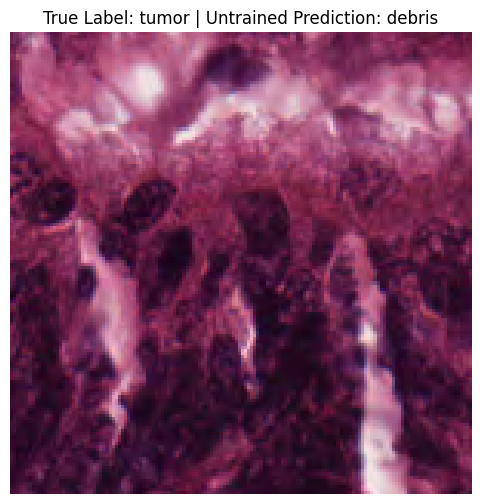

In [ ]:


# Find the index of the highest probability in the random vector
predicted_index = np.argmax(prediction)
predicted_confidence = np.max(prediction)

# Define our class names in the correct order
class_names = sorted(pd.get_dummies(labels).columns)
true_label_name = class_names[true_label_index]

# Map the index to the class name
predicted_label_name = class_names[predicted_index]

print(f"The highest value in the random vector is at index: {predicted_index}")
print(f"--> This corresponds to the random guess: '{predicted_label_name}'")
print(f"--> The model's confidence in its random guess is: {predicted_confidence:.2%}\n")
print("Notice that the prediction is likely incorrect and the confidence is low. This is what we expect from an untrained model!")


# Visualize
plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"True Label: {true_label_name} | Untrained Prediction: {predicted_label_name}", fontsize=12)
plt.axis("off")
plt.show()

In [ ]:

cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       165,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,712 (744.97 KB)

 Trainable params: 190,712 (744.97 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.1914 - categorical_crossentropy: 2.0065 - loss: 2.0065 - val_accuracy: 0.3125 - val_categorical_crossentropy: 1.6837 - val_loss: 1.6837
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2917 - categorical_crossentropy: 1.7807 - loss: 1.7807 - val_accuracy: 0.3086 - val_categorical_crossentropy: 1.5232 - val_loss: 1.5232
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3073 - categorical_crossentropy: 1.6045 - loss: 1.6045 - val_accuracy: 0.3750 - val_categorical_crossentropy: 1.4392 - val_loss: 1.4392
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3880 - categorical_crossentropy: 1.5149 - loss: 1.5149 - val_accuracy: 0.3906 - val_categorical_crossentropy: 1.3267 - val_loss: 1.3267
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4010 - categorical_crossentropy: 1.4558 - loss: 1.4558 - val_accuracy: 0.1641 - val_categorical_crossentropy: 1.6882 - val_loss: 1.

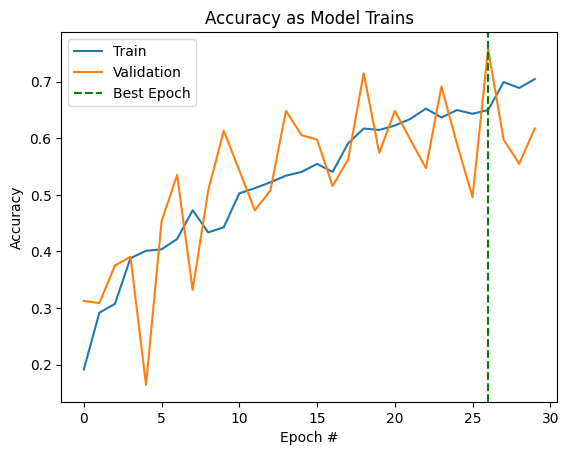

In [ ]:


history= cnn.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 30)

plot_metric(history)


In [ ]:

sample_image = X_test[8]
true_label_index = np.argmax(y_test[8])

--- Decoding the Trained Model's Guess ---

The model's raw output for the image:

[1.3380009e-05 2.4841674e-02 3.1401427e-04 1.2669913e-06 1.0676206e-02
 7.2759140e-01 1.5043850e-03 2.3505776e-01] 

The highest value in the vector is at index: 5
--> This corresponds to the: 'mucosa' label
--> The model's confidence in its prediction is: 72.76%

How did the trained model do?


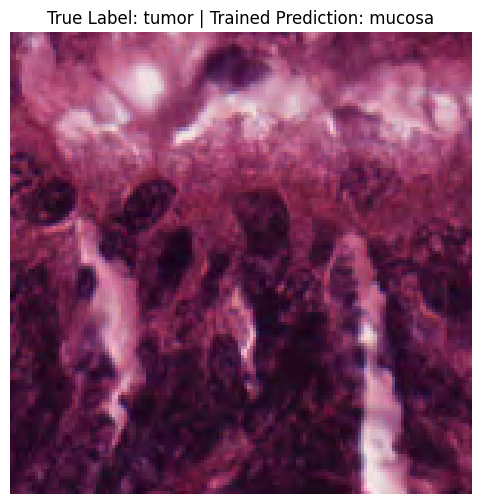

In [ ]:

sample_image_expanded = np.expand_dims(sample_image, axis=0)

# Get the model's prediction.
prediction_vector = cnn.predict(sample_image_expanded, verbose=0)


print("--- Decoding the Trained Model's Guess ---\n")
print(f"The model's raw output for the image:\n")
print(prediction_vector[0],"\n")

predicted_index = np.argmax(prediction_vector)
predicted_confidence = np.max(prediction_vector)

predicted_label_name = class_names[predicted_index]

print(f"The highest value in the vector is at index: {predicted_index}")
print(f"--> This corresponds to the: '{predicted_label_name}' label")
print(f"--> The model's confidence in its prediction is: {predicted_confidence:.2%}\n")
print("How did the trained model do?")


plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"True Label: {true_label_name} | Trained Prediction: {predicted_label_name}", fontsize=12)
plt.axis("off")
plt.show()

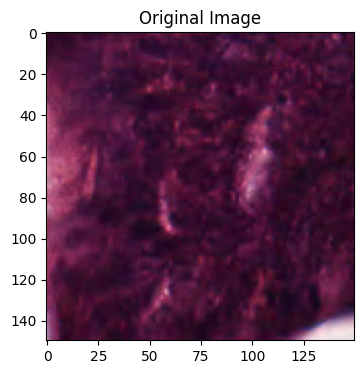

In [ ]:

from numpy import flipud, fliplr
from skimage.transform import rotate
from skimage.exposure import adjust_gamma

original_image = X_train[np.random.randint(len(X_train))]
plt.figure(figsize=(8, 4))
plt.imshow(original_image)
plt.title('Original Image')
plt.show()

--- 1. Vertical Flip ---


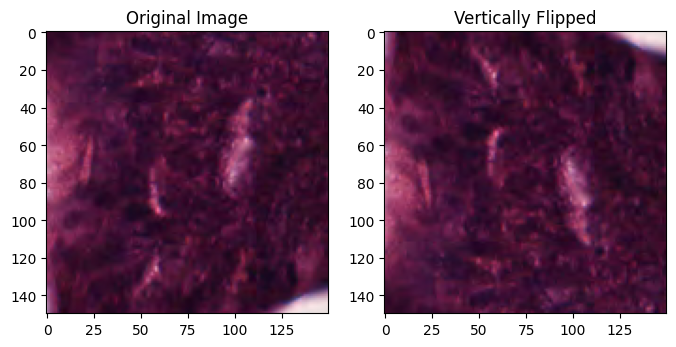

In [ ]:
# Flipping Upside Down (flipud)
print("--- 1. Vertical Flip ---")
augmented_ud = flipud(original_image)

f, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[1].imshow(augmented_ud)
ax[1].set_title('Vertically Flipped')
plt.show()


--- 2. Horizontal Flip ---


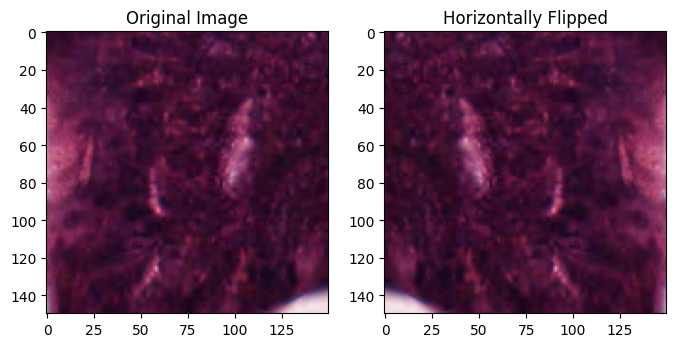

In [ ]:
# Flipping Left-to-Right (fliplr)
print("\n--- 2. Horizontal Flip ---")
augmented_lr = fliplr(original_image)

f, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[1].imshow(augmented_lr)
ax[1].set_title('Horizontally Flipped')
plt.show()


--- 3. Rotation ---


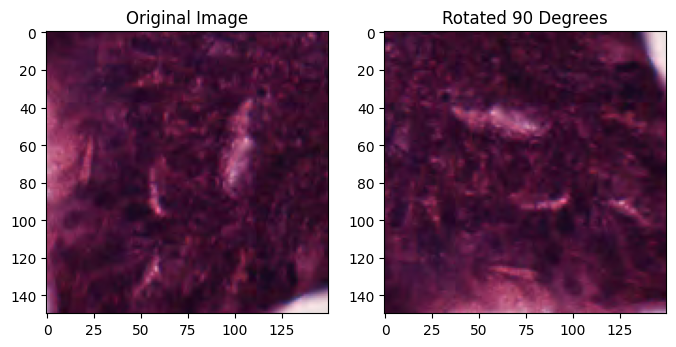

In [ ]:
# Rotation
print("\n--- 3. Rotation ---")
# We rotate by 90 degrees. resize=False is important to keep the image dimensions the same.
augmented_rot = rotate(original_image, angle=90, resize=False)

f, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[1].imshow(augmented_rot)
ax[1].set_title('Rotated 90 Degrees')
plt.show()


--- 4. Brightness Change ---


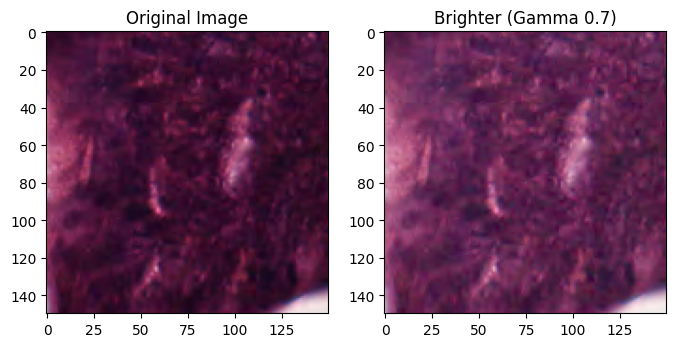

In [ ]:
# Example 4: Brightness Change (Gamma Correction)
print("\n--- 4. Brightness Change ---")
# Gamma < 1 makes the image brighter. Gamma > 1 makes it darker.
augmented_bright = adjust_gamma(original_image, gamma=0.7)

f, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[1].imshow(augmented_bright)
ax[1].set_title('Brighter (Gamma 0.7)')
plt.show()

In [ ]:
import random

# A function that randomly applies one of several augmentations
def create_random_augmented_image(original_image):

    # Randomly choose which augmentation to apply
    choice = random.randint(0, 3)

    if choice == 0:
        # Option 0: Flip upside down
        new_image = flipud(original_image)
    elif choice == 1:
        # Option 1: Flip left-to-right
        new_image = fliplr(original_image)
    elif choice == 2:
        # Option 2: Rotate 90 degrees
        new_image = rotate(original_image, angle=90, resize=False)
    else:
        # Option 3: Make it brighter
        new_image = adjust_gamma(original_image, gamma=0.7)

    return new_image

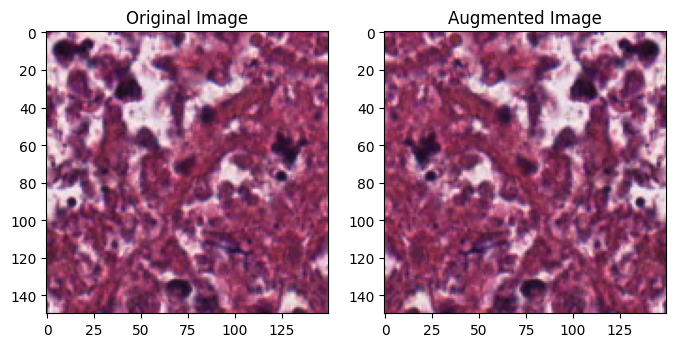

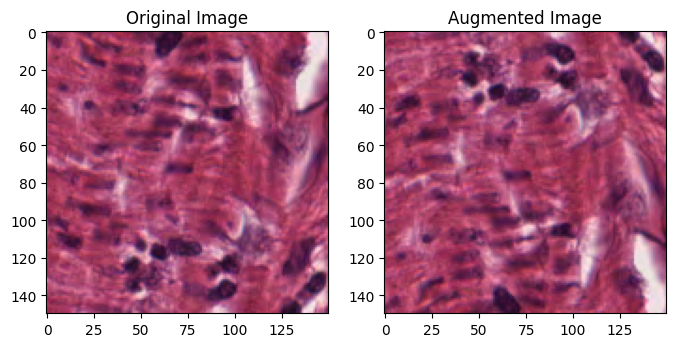

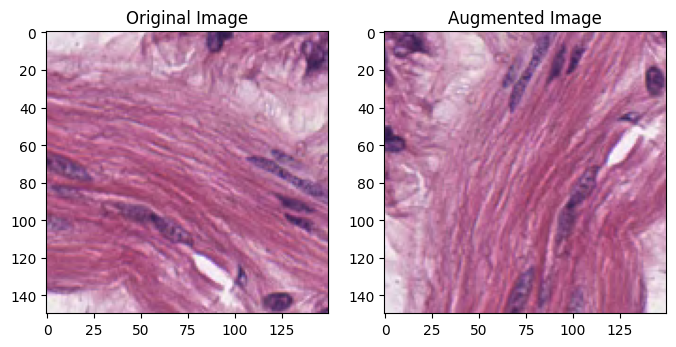

In [ ]:

for image in X_train[:3]:
  f, ax = plt.subplots(ncols=2, figsize=(8, 4))
  ax[0].imshow(image)
  ax[0].set_title('Original Image')
  augmented_image = create_random_augmented_image(image)
  ax[1].imshow(augmented_image)
  ax[1].set_title('Augmented Image')
  plt.show()

In [ ]:
# Create two empty lists to hold our new data
X_train_augment_list = []
y_train_augment_list = []

# Loop through the images to create an augmented dataset
for i in range(len(X_train)):

    # Get the original image and its label
    original_image = X_train[i]
    original_label = y_train[i]

    # Create a new, randomly augmented version of the image

    new_augmented_image = create_random_augmented_image(original_image)

    # Append the new image and its original label to our lists
    X_train_augment_list.append(new_augmented_image)
    y_train_augment_list.append(original_label)

# Convert the lists to NumPy arrays
X_train_augment = np.array(X_train_augment_list)
y_train_augment = np.array(y_train_augment_list)

# Concatenate the original and augmented data to form our combined dataset
X_train_combined = np.concatenate((X_train, X_train_augment), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augment), axis=0)

# Verify the new shapes
print("Dimensions of original X_train:", X_train.shape)
print("Dimensions of augmented X:", X_train_augment.shape)
print("Dimensions of combined X_train:", X_train_combined.shape)
print("Shape of combined y_train:", y_train_combined.shape)

Dimensions of original X_train: (768, 150, 150, 3)
Dimensions of augmented X: (768, 150, 150, 3)
Dimensions of combined X_train: (1536, 150, 150, 3)
Shape of combined y_train: (1536, 8)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.1875 - categorical_crossentropy: 1.9721 - loss: 1.9721 - val_accuracy: 0.3320 - val_categorical_crossentropy: 1.6121 - val_loss: 1.6121
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2799 - categorical_crossentropy: 1.6974 - loss: 1.6974 - val_accuracy: 0.3281 - val_categorical_crossentropy: 1.4954 - val_loss: 1.4954
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3359 - categorical_crossentropy: 1.6332 - loss: 1.6332 - val_accuracy: 0.5742 - val_categorical_crossentropy: 1.3746 - val_loss: 1.3746
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3802 - categorical_crossentropy: 1.4549 - loss: 1.4549 - val_accuracy: 0.3945 - val_categorical_crossentropy: 1.3282 - val_loss: 1.3282
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4258 - categorical_crossentropy: 1.3796 - loss: 1.3796 - val_accuracy: 0.3672 - val_categorical_crossentropy: 1.3352 - val_loss: 1

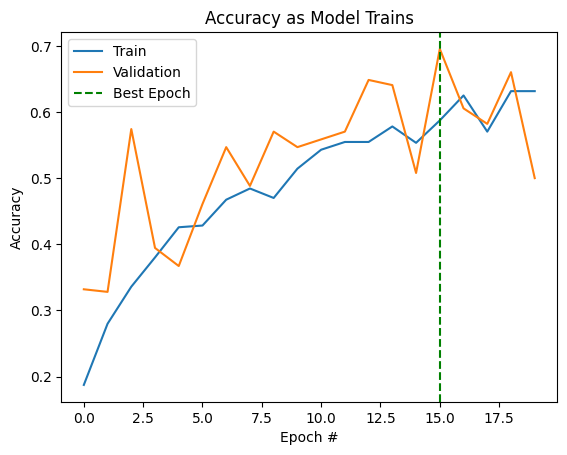

In [ ]:
cnn = construct_model()
history = cnn.fit(X_train, y_train, batch_size=64, epochs=20, validation_data=(X_test, y_test))
plot_metric(history, metric='accuracy')

In [ ]:

from tensorflow.keras.applications import ResNet50
res_net = ResNet50(include_top=True)
res_net.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
from tensorflow.keras import Model

# Get ResNet's output from the layer before the last Dense layer, and add on a
# custom Dense layer and Dropout layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

new_output_layer = Dense(len(class_names), activation='softmax')(x)

input = res_net.input
transfer_cnn = Model(input, new_output_layer)


transfer_cnn.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 23,797,896 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Make all layers untrainable by freezing weights
for layer in transfer_cnn.layers:
  layer.trainable = False  # Freeze all layers to start

for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

# Compiles new model using the correct loss, optimizer, and metrics
transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)


transfer_cnn.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.image import resize_with_pad

def ResizeImages(images, height, width):
  return np.array([resize_with_pad(image, height, width, antialias=True) for image in images]).astype(int)

X_train_unnormed = X_train/ 255.0
X_test_unnormed = X_test / 255.0
X_train_resized = ResizeImages(X_train, 224, 224)
X_test_resized = ResizeImages(X_test, 224, 224)

print("Dim X_train_resized:", X_train_resized.shape)
print("Dim X_test_resized:", X_test_resized.shape)


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step
              precision    recall  f1-score   support

     adipose       0.00      0.00      0.00        43
     complex       0.00      0.00      0.00        29
      debris       0.00      0.00      0.00        23
       empty       0.00      0.00      0.00        39
      lympho       0.00      0.00      0.00        20
      mucosa       0.12      1.00      0.22        31
      stroma       0.00      0.00      0.00        34
       tumor       0.00      0.00      0.00        37

    accuracy                           0.12       256
   macro avg       0.02      0.12      0.03       256
weighted avg       0.01      0.12      0.03       256



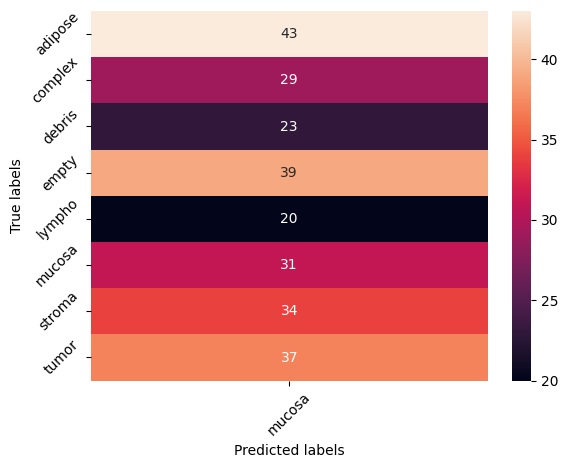

In [ ]:


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
logits = transfer_cnn.predict(X_test_resized)
vals = np.argmax(logits, axis=1)
y_pred = np.array([one_hot_encoding_to_label_dict[val] for val in vals])
y_true = np.array([one_hot_encoding_to_label_dict[y_val] for y_val in np.argmax(y_test, axis=1)])

sns.heatmap(pd.crosstab(y_true, y_pred), annot=True)
print(classification_report(y_true, y_pred))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

Found a misclassification for 'empty'.
The model incorrectly predicted 'mucosa' when the true label was 'empty'.

--- Visualizing the Specific Error ---


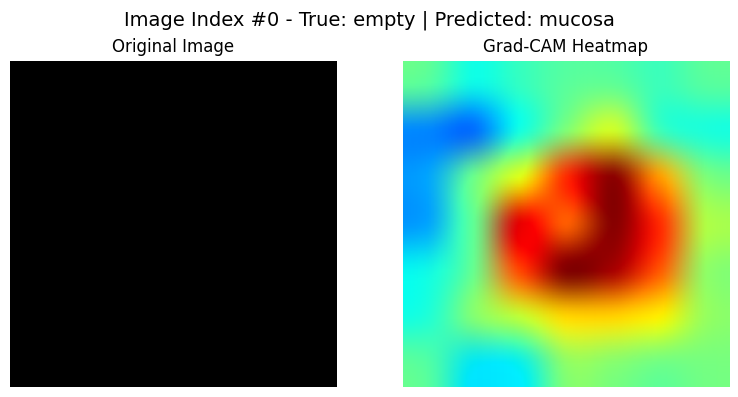


--- For comparison, here are 5 correct examples of 'mucosa' ---


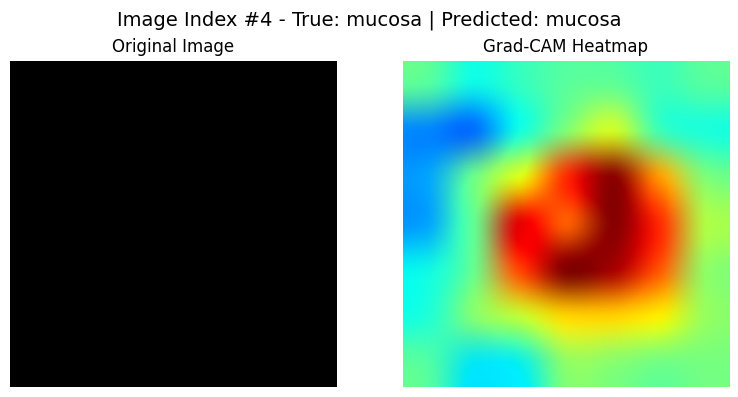

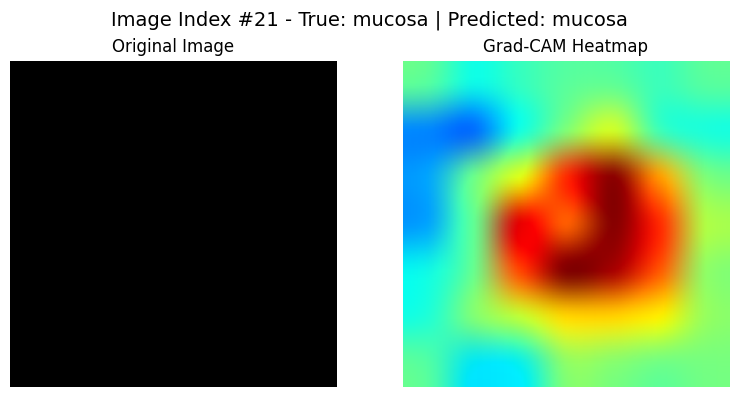

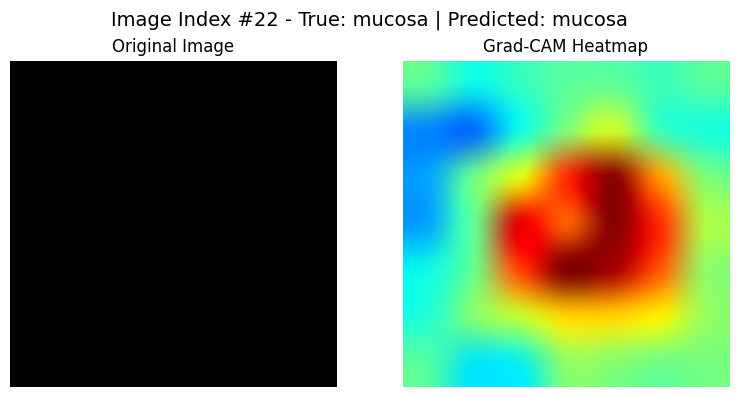

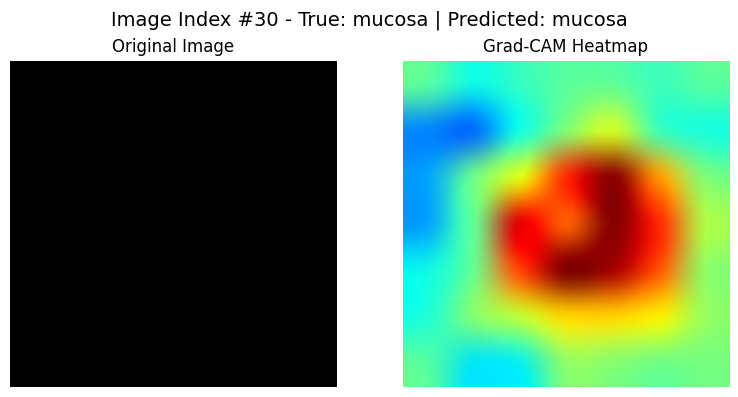

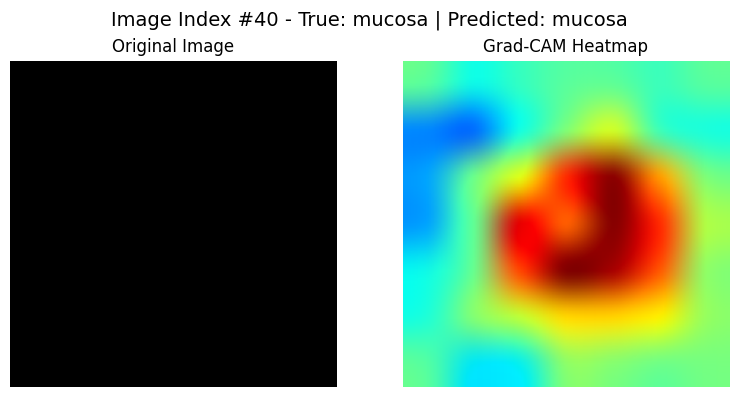


--- And here are 5 correct examples of the true class, 'empty' ---


In [ ]:
# This list now matches the actual class names used by the model.
class_names_for_dropdown = ['adipose', 'complex', 'debris', 'empty', 'lympho', 'mucosa', 'stroma', 'tumor']
selected_tissue_type = 'empty'  #@param ["adipose", "complex", "debris", "empty", "lympho", "mucosa", "stroma", "tumor"]

# Initial Model and Prediction Setup
# Find the name of the last convolutional layer in the transfer learning model
last_conv_layer_name = None
for layer in reversed(transfer_cnn.layers):
    if 'conv' in layer.name:  # A more robust way to find a convolutional layer
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("Could not find a Conv2D layer in the model.")

# Get predictions for the entire test set
all_preds = transfer_cnn.predict(X_test_resized, verbose=0)
predicted_indices = np.argmax(all_preds, axis=1)
true_indices = np.argmax(y_test, axis=1)

class_names = sorted(pd.get_dummies(labels).columns)

target_class_index = class_names.index(selected_tissue_type)

misclassification_indices = np.where((true_indices == target_class_index) & (predicted_indices != target_class_index))[0]

if len(misclassification_indices) > 0:
    # SCENARIO A: A mistake was found.
    mistake_index = misclassification_indices[0]  # Focus on the first mistake

    true_label = class_names[true_indices[mistake_index]]
    predicted_label = class_names[predicted_indices[mistake_index]]

    print(f"Found a misclassification for '{selected_tissue_type}'.")
    print(f"The model incorrectly predicted '{predicted_label}' when the true label was '{true_label}'.")
    print("\n--- Visualizing the Specific Error ---")
    plot_single_gradcam(mistake_index, transfer_cnn, last_conv_layer_name, class_names, X_test_resized, y_test)

    # Find and visualize 5 correct examples of what the model THOUGHT it saw
    print(f"\n--- For comparison, here are 5 correct examples of '{predicted_label}' ---")
    correct_predicted_indices = np.where((true_indices == class_names.index(predicted_label)) & (predicted_indices == true_indices))[0][:5]
    for i in correct_predicted_indices:
        plot_single_gradcam(i, transfer_cnn, last_conv_layer_name, class_names, X_test_resized, y_test)

    # Find and visualize 5 correct examples of what the model SHOULD have seen
    print(f"\n--- And here are 5 correct examples of the true class, '{true_label}' ---")
    correct_true_indices = np.where((true_indices == target_class_index) & (predicted_indices == true_indices))[0][:5]
    for i in correct_true_indices:
        plot_single_gradcam(i, transfer_cnn, last_conv_layer_name, class_names, X_test_resized, y_test)

else:
    # SCENARIO B: No mistakes were found.
    print(f"No misclassifications found for '{selected_tissue_type}' in the test set! The model was correct every time.")
    print(f"\n--- Showing 5 correctly identified examples of '{selected_tissue_type}' ---")

    correct_indices = np.where((true_indices == target_class_index) & (predicted_indices == true_indices))[0][:5]
    if len(correct_indices) == 0:
        print(f"Could not find any examples of '{selected_tissue_type}' in the test set.")
    else:
        for i in correct_indices:
            plot_single_gradcam(i, transfer_cnn, last_conv_layer_name, class_names, X_test_resized, y_test)

In [ ]:
from tensorflow.keras.applications import ResNet50
res_net = ResNet50(include_top=True)
res_net.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
from tensorflow.keras import Model

# Get ResNet's output from the layer before the last Dense layer, and add on a
# custom Dense layer and Dropout layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

new_output_layer = Dense(len(class_names), activation='softmax')(x)

# The next couple lines are necessary to build the complete network using the
# majority of the ResNet50 network as well as our custom layers from above.
input = res_net.input
transfer_cnn = Model(input, new_output_layer)


transfer_cnn.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 23,797,896 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Make all layers untrainable by freezing weights (except for last layer)
for layer in transfer_cnn.layers:
  layer.trainable = False  # Freeze all layers to start

# Set the final three layers as trainable=True
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True
transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)

transfer_cnn.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
X_train_combined_unnormed = X_train_combined / 255.0
X_train_combined_resized = ResizeImages(X_train_combined_unnormed, 224, 224)

print("Dimensions of combined X_train_resized:", X_train_combined_resized.shape)

In [ ]:
from tensorflow.keras import Model

output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

new_output_layer = Dense(len(class_names), activation='softmax')(x)

input = res_net.input
transfer_cnn = Model(input, new_output_layer)

transfer_cnn.summary()

In [ ]:
 history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The model was redefined with a corrected output layer in a previous step, but was not re-compiled after this change. To resolve the `ValueError` and prepare the model for training, it needs to be explicitly re-compiled with its training configuration.



In [ ]:
for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The model was redefined with a corrected output layer in a previous step, but was not re-compiled after this change. To resolve the `ValueError` and prepare the model for training, it needs to be explicitly re-compiled with its training configuration.



In [ ]:
for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The `NameError` indicates that `transfer_cnn` is not defined in the current execution scope. This is because the model definition, recompilation, and training were split across multiple cells, and the latest `transfer_cnn` definition was not re-executed before attempting compilation and training in a subsequent cell. To fix this, I need to combine the latest model definition with the compilation and training steps into a single code block to ensure `transfer_cnn` is properly defined and then used.



In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout

# Get ResNet's output from the layer before the last Dense layer, and add on a
# custom Dense layer and Dropout layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

# Correct the number of output units to match the 8 classes
new_output_layer = Dense(len(class_names), activation='softmax')(x)


# The next couple lines are necessary to build the complete network using the
# majority of the ResNet50 network as well as our custom layers from above.
input = res_net.input
transfer_cnn = Model(input, new_output_layer)

# Make all layers untrainable by freezing weights (except for last layer)
for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)

transfer_cnn.summary()
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The previous attempt failed because `res_net` was not defined within the scope of the combined cell. To fix this, I will include the import and initialization of `ResNet50` (which defines `res_net`) at the beginning of the code block, along with the `transfer_cnn` definition, compilation, and training steps.



In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout

# Define res_net (ResNet50 model)
res_net = ResNet50(include_top=True)

# Get ResNet's output from the layer before the last Dense layer, and add on a
# custom Dense layer and Dropout layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

# Correct the number of output units to match the 8 classes
new_output_layer = Dense(len(class_names), activation='softmax')(x)


# The next couple lines are necessary to build the complete network using the
# majority of the ResNet50 network as well as our custom layers from above.
input = res_net.input
transfer_cnn = Model(input, new_output_layer)

# Make all layers untrainable by freezing weights (except for last layer)
for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)

transfer_cnn.summary()
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The `NameError` for `class_names` indicates that this variable was not defined when the combined code block was executed. To resolve this, I need to include the definition of `class_names` within the code block itself, ensuring it is available before being used to set the output layer size.



In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd # Import pandas for get_dummies

# Define class_names
class_names = sorted(pd.get_dummies(labels).columns)

# Define res_net (ResNet50 model)
res_net = ResNet50(include_top=True)

# Get ResNet's output from the layer before the last Dense layer, and add on a
# custom Dense layer and Dropout layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

# Correct the number of output units to match the 8 classes
new_output_layer = Dense(len(class_names), activation='softmax')(x)


# The next couple lines are necessary to build the complete network using the
# majority of the ResNet50 network as well as our custom layers from above.
input = res_net.input
transfer_cnn = Model(input, new_output_layer)

# Make all layers untrainable by freezing weights (except for last layer)
for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)

transfer_cnn.summary()
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)

**Reasoning**:
The `NameError` for `labels` indicates that this variable is not defined within the scope of the consolidated code block, even though it was defined in a previous cell. Since `labels` are derived from the dataset, and their unique values form the class names, the most robust way to resolve this issue in a self-contained code block is to explicitly define `class_names` as a static list of the known class names. This ensures the model can be correctly built and trained without relying on `labels` being globally accessible in the new execution context.



In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout

# defines class_names as a static list of strings
class_names = ['adipose', 'complex', 'debris', 'empty', 'lympho', 'mucosa', 'stroma', 'tumor']

# Defines res_net (ResNet50 model)
res_net = ResNet50(include_top=True)

# Gets ResNet's output from the layer before the last Dense layer
output_from_resnet = res_net.layers[-2].output
x = Dense(128, activation='relu')(output_from_resnet)
x = Dropout(0.50)(x) # Add 50% dropout

new_output_layer = Dense(len(class_names), activation='softmax')(x)


input = res_net.input
transfer_cnn = Model(input, new_output_layer)

for layer in transfer_cnn.layers:
  layer.trainable = False
for layer in transfer_cnn.layers[-3:]:
  layer.trainable = True

transfer_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'categorical_crossentropy']
)

transfer_cnn.summary()
history_transfer = transfer_cnn.fit(X_train_combined_resized, y_train_combined, epochs=30, validation_data=(X_test_resized, y_test))
plot_metric(history_transfer)